# Skin Disease Classification — ResNet50 Baseline (Paper Replication)
**Project:** Multimodal Skin Disease Detection  
**Student:** Mohamed Alhusein Abdalla — BUE AI Department  
**Supervisor:** Dr. Gehad Ismail Sayed  
**Goal:** Replicate the paper's pipeline as closely as possible on the 7-class dataset.  
**Platform:** Vast.ai H200  

---
### Classes
Burn, Cancer, Eczema, Lupus, Normal, Psoriasis, Urticaria  
*(Paper had 5 classes — we have 7: added Eczema and Psoriasis)*

---
### Pipeline Summary
- ResNet50 pretrained on ImageNet, **frozen backbone**
- **Stratified** 70/15/15 split (improvement over paper's random split)
- ROS applied **ONLY on training set AFTER split**
- Paper's exact augmentation parameters
- Adam LR=0.001, Batch=32, CrossEntropyLoss
- Early stopping patience=10, max epochs=50
- **Primary metric: Macro F1** | Secondary: Accuracy, AUC-ROC

## Step 0 — Configuration

In [24]:
# ============================================================
# CONFIGURATION — edit paths if needed
# ============================================================

DATASET_PATH = "/root/dataset/Skin Disease Dataset"
CLASSES     = ["Burn", "Cancer", "Lupus", "Normal", "Urticaria"]
NUM_CLASSES = 5

TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15

IMAGE_SIZE   = 224
BATCH_SIZE   = 32
NUM_EPOCHS   = 50
LR           = 0.001
PATIENCE     = 10
NUM_WORKERS  = 4
SEED         = 42

# Augmentation — exact values from paper
ROTATION_DEGREES = 6
WIDTH_SHIFT      = 0.134
HEIGHT_SHIFT     = 0.134
SHEAR_RADIANS    = 0.1
ZOOM_MIN         = 0.8
ZOOM_MAX         = 1.2

SAVE_DIR    = "/root/outputs/resnet50_baseline"
MODEL_NAME  = "resnet50_baseline"

import os
os.makedirs(SAVE_DIR, exist_ok=True)
print('Config loaded.')
print(f'Classes ({NUM_CLASSES}): {CLASSES}')
print(f'Save dir: {SAVE_DIR}')

Config loaded.
Classes (5): ['Burn', 'Cancer', 'Lupus', 'Normal', 'Urticaria']
Save dir: /root/outputs/resnet50_baseline


## Step 1 — Install Libraries

In [25]:
import sys
!{sys.executable} -m pip install -q timm scikit-learn imbalanced-learn torchmetrics matplotlib seaborn pandas Pillow tqdm

## Step 2 — Imports

In [26]:
import os, random, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchmetrics.classification import MulticlassF1Score, MulticlassAUROC

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import RandomOverSampler

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA H200
VRAM: 150.1 GB


## Step 3 — Extract Dataset

In [27]:
# Upload the zip via JupyterLab file browser to /, then run this cell
ZIP_PATH     = '/OneDrive_2026-04-07.zip'
EXTRACT_PATH = '/root/dataset'

if not os.path.exists(DATASET_PATH):
    print('Extracting dataset...')
    import zipfile
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_PATH)
    print('Done.')
else:
    print('Dataset already extracted.')

print('\nImage counts per class:')
for cls in CLASSES:
    p = os.path.join(DATASET_PATH, cls)
    n = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f'  {cls:12s}: {n}')

Dataset already extracted.

Image counts per class:
  Burn        : 101
  Cancer      : 79
  Lupus       : 40
  Normal      : 56
  Urticaria   : 44


## Step 4 — EDA

In [28]:
# Build master dataframe
records = []
for cls in CLASSES:
    for fname in os.listdir(os.path.join(DATASET_PATH, cls)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            records.append({
                'path':      os.path.join(DATASET_PATH, cls, fname),
                'label':     cls,
                'label_idx': CLASSES.index(cls)
            })

df = pd.DataFrame(records)
print(f'Total images: {len(df)}')
print(df['label'].value_counts())

Total images: 320
label
Burn         101
Cancer        79
Normal        56
Urticaria     44
Lupus         40
Name: count, dtype: int64


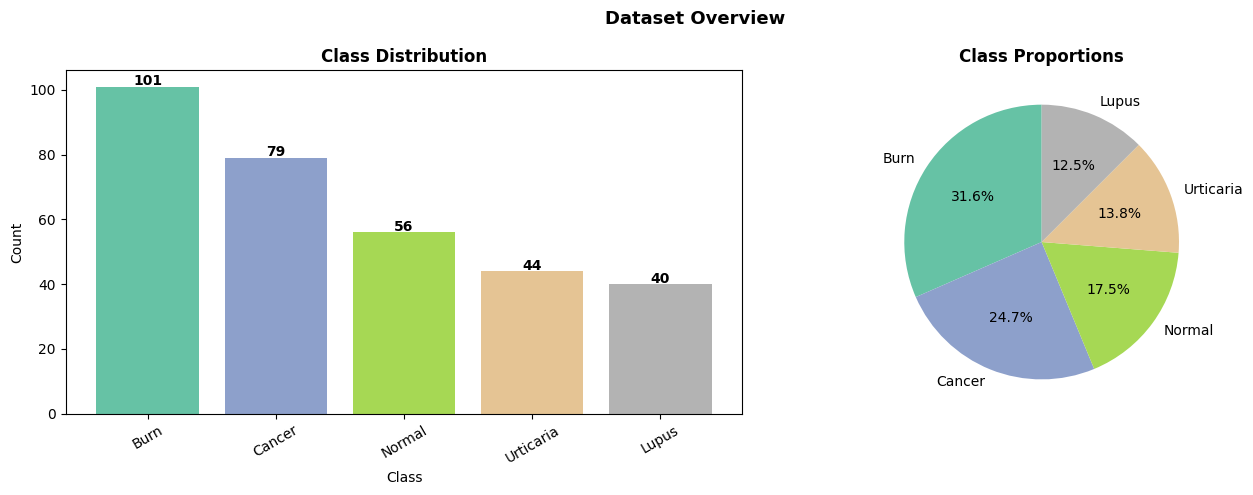

Imbalance ratio: 2.52:1


In [29]:
# Class distribution plot
counts = df['label'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Proportions', fontweight='bold')

plt.suptitle('Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio: {counts.max()/counts.min():.2f}:1')

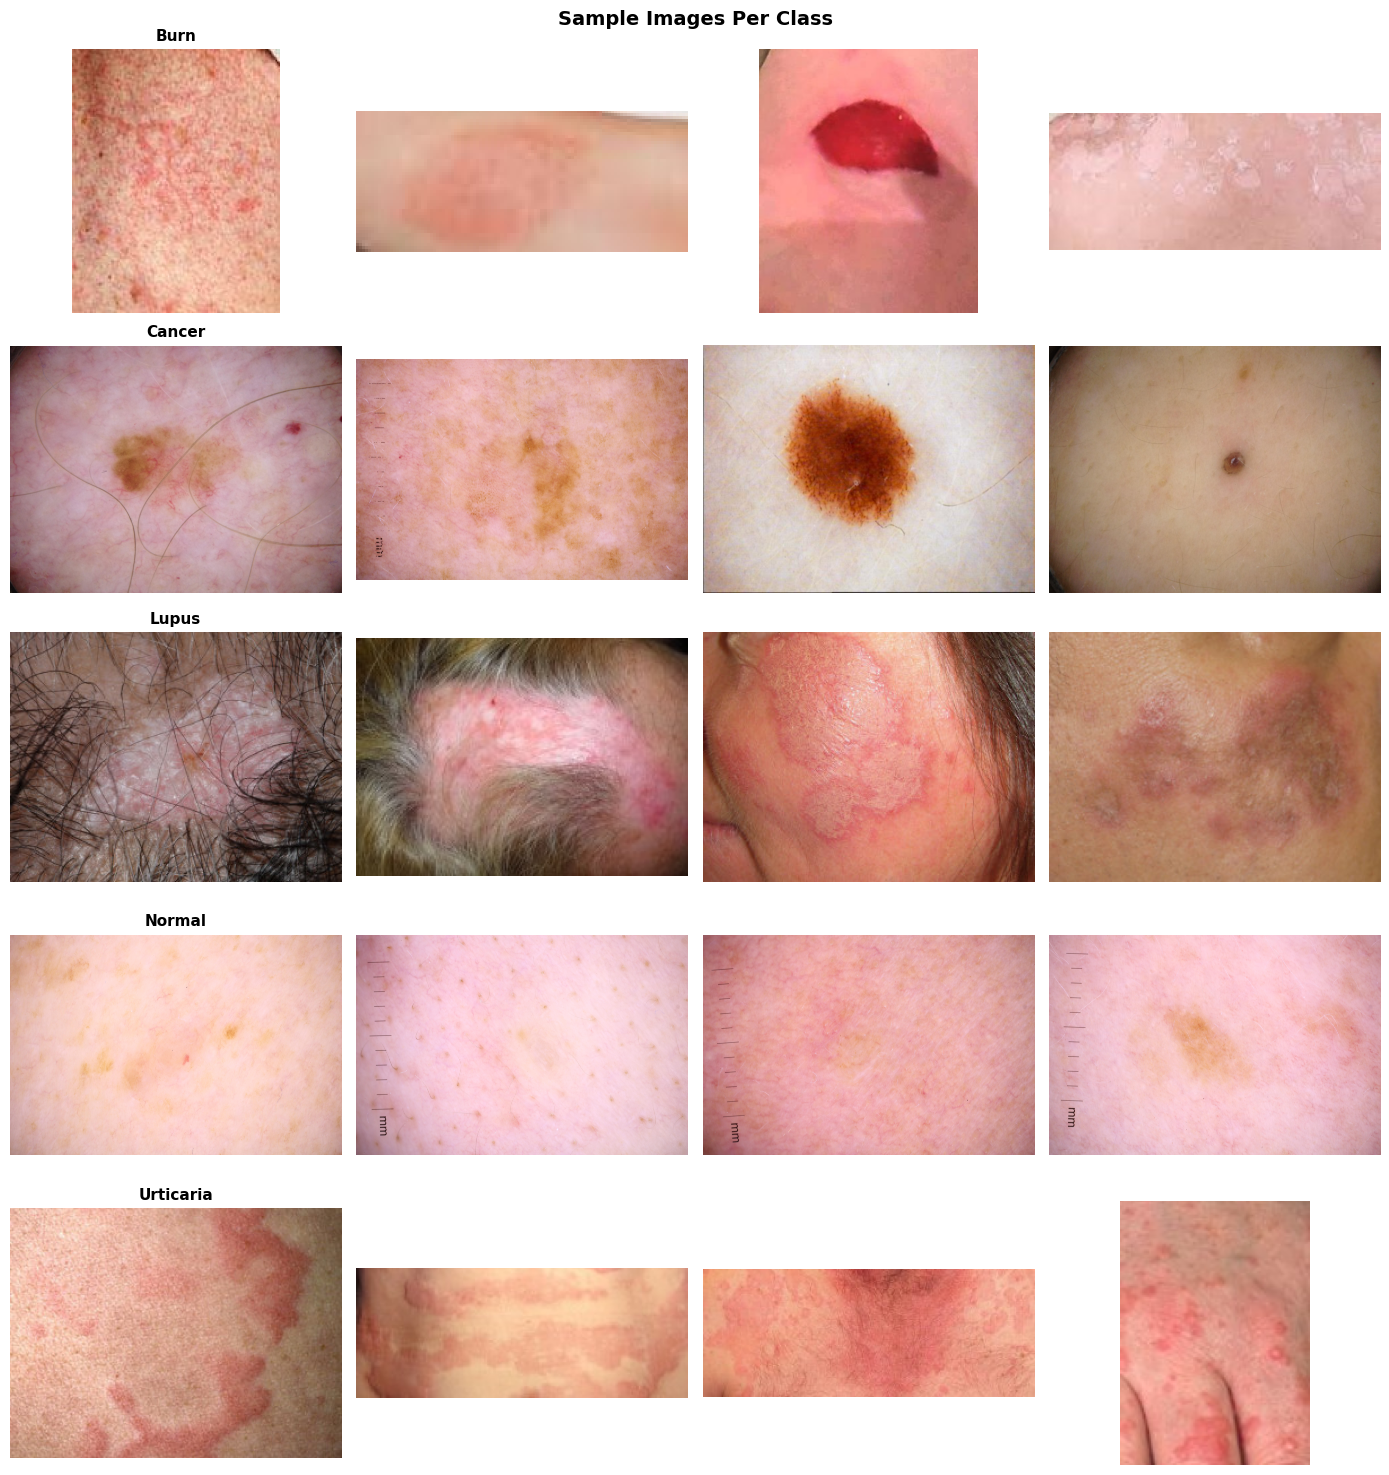

In [30]:
# Sample images per class
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(14, NUM_CLASSES * 3))
for i, cls in enumerate(CLASSES):
    cls_df = df[df['label'] == cls].sample(min(4, len(df[df['label']==cls])), random_state=SEED)
    for j, (_, row) in enumerate(cls_df.iterrows()):
        img = Image.open(row['path']).convert('RGB')
        axes[i][j].imshow(img)
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_title(cls, fontsize=11, fontweight='bold')
plt.suptitle('Sample Images Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 5 — Stratified Split (70 / 15 / 15)

In [31]:
# SPLIT BEFORE OVERSAMPLING — no exceptions
paths  = df['path'].values
labels = df['label_idx'].values

# Step 1: carve out test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    paths, labels, test_size=TEST_RATIO, stratify=labels, random_state=SEED
)

# Step 2: split remaining into train / val
val_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_adjusted, stratify=y_trainval, random_state=SEED
)

print(f'Train : {len(X_train):4d} images')
print(f'Val   : {len(X_val):4d} images')
print(f'Test  : {len(X_test):4d} images')
print(f'Total : {len(X_train)+len(X_val)+len(X_test):4d} images')

print('\nTrain class counts after split:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:12s}: {(y_train==i).sum()}')
print('\nTest class counts after split:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:12s}: {(y_test==i).sum()}')

Train :  224 images
Val   :   48 images
Test  :   48 images
Total :  320 images

Train class counts after split:
  Burn        : 71
  Cancer      : 55
  Lupus       : 28
  Normal      : 40
  Urticaria   : 30

Test class counts after split:
  Burn        : 15
  Cancer      : 12
  Lupus       : 6
  Normal      : 8
  Urticaria   : 7


## Step 6 — Random Oversampling (Training Only)

In [32]:
ros = RandomOverSampler(random_state=SEED)
X_train_ros, y_train_ros = ros.fit_resample(X_train.reshape(-1, 1), y_train)
X_train_ros = X_train_ros.flatten()

print(f'Before ROS: {len(X_train):4d} training images')
print(f'After  ROS: {len(X_train_ros):4d} training images')
print('\nPost-ROS class distribution:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:12s}: {(y_train_ros==i).sum()}')

Before ROS:  224 training images
After  ROS:  355 training images

Post-ROS class distribution:
  Burn        : 71
  Cancer      : 71
  Lupus       : 71
  Normal      : 71
  Urticaria   : 71


## Step 7 — Transforms (Paper's Augmentation)

In [33]:
SHEAR_DEG  = math.degrees(SHEAR_RADIANS)  # 0.1 rad ≈ 5.73°
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=ROTATION_DEGREES,
        translate=(WIDTH_SHIFT, HEIGHT_SHIFT),
        shear=SHEAR_DEG,
        scale=(ZOOM_MIN, ZOOM_MAX),
        fill=0  # paper used reflect; torchvision does not support reflect fill
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Transforms defined.')
print(f'  Rotation    : ±{ROTATION_DEGREES}°')
print(f'  Translate   : {WIDTH_SHIFT*100:.1f}% W / {HEIGHT_SHIFT*100:.1f}% H')
print(f'  Shear       : {SHEAR_DEG:.2f}°')
print(f'  Zoom        : [{ZOOM_MIN}, {ZOOM_MAX}]')
print(f'  H/V Flip    : True')
print(f'  Fill        : 0 (black) — paper used reflect, not supported in torchvision')

Transforms defined.
  Rotation    : ±6°
  Translate   : 13.4% W / 13.4% H
  Shear       : 5.73°
  Zoom        : [0.8, 1.2]
  H/V Flip    : True
  Fill        : 0 (black) — paper used reflect, not supported in torchvision


## Step 8 — Dataset & DataLoaders

In [34]:
class SkinDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


train_dataset = SkinDataset(X_train_ros, y_train_ros, transform=train_transform)
val_dataset   = SkinDataset(X_val,       y_val,       transform=val_test_transform)
test_dataset  = SkinDataset(X_test,      y_test,      transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, multiprocessing_context='fork', pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, multiprocessing_context='fork', pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, multiprocessing_context='fork', pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 12
Val batches   : 2
Test batches  : 2


## Step 9 — Model (ResNet50, Frozen Backbone)

In [35]:
def build_resnet50(num_classes):
    """
    ResNet50 pretrained on ImageNet, backbone fully frozen.
    Head: GAP (built-in) -> Dense(256, ReLU) -> Dense(num_classes)
    Matches paper architecture exactly.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # Replace head (ResNet50 already has GAP before fc)
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Linear(256, num_classes)
        # No explicit Softmax: CrossEntropyLoss applies log-softmax internally
    )
    return model


model = build_resnet50(NUM_CLASSES).to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_p:,}')
print(f'Trainable params : {trainable_p:,}  (head only)')
print(f'Frozen params    : {total_p - trainable_p:,}  (backbone)')

Total params     : 24,033,861
Trainable params : 525,829  (head only)
Frozen params    : 23,508,032  (backbone)


## Step 10 — Loss, Optimizer, Metrics

In [36]:
# Paper: plain CrossEntropyLoss, Adam LR=0.001, no scheduler
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=LR)

f1_metric  = MulticlassF1Score(num_classes=NUM_CLASSES, average='macro').to(DEVICE)
auc_metric = MulticlassAUROC(num_classes=NUM_CLASSES, average='macro').to(DEVICE)

print('Loss      : CrossEntropyLoss (no weighting — paper replication)')
print('Optimizer : Adam, LR=0.001')
print('Scheduler : None (paper had none)')
print('Metrics   : Macro F1 (primary), Accuracy, AUC-ROC')

Loss      : CrossEntropyLoss (no weighting — paper replication)
Optimizer : Adam, LR=0.001
Scheduler : None (paper had none)
Metrics   : Macro F1 (primary), Accuracy, AUC-ROC


## Step 11 — Train / Eval Functions

In [37]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.append(preds)
        all_labels.append(labels)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return total_loss / total, correct / total, f1_metric(all_preds, all_labels).item()


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc='Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs)
        loss = criterion(out, labels)

        total_loss += loss.item() * imgs.size(0)
        preds = out.argmax(dim=1)
        probs = torch.softmax(out, dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.append(preds)
        all_labels.append(labels)
        all_probs.append(probs)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_probs  = torch.cat(all_probs)
    macro_f1   = f1_metric(all_preds, all_labels).item()
    macro_auc  = auc_metric(all_probs, all_labels).item()
    return total_loss/total, correct/total, macro_f1, macro_auc, all_preds, all_labels, all_probs


print('Functions defined.')

Functions defined.


## Step 12 — Training Loop with Early Stopping

In [38]:
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
           'train_f1':[], 'val_f1':[], 'val_auc':[]}

best_val_f1     = 0.0
best_epoch      = 0
patience_ctr    = 0
best_model_path = os.path.join(SAVE_DIR, f'{MODEL_NAME}_best.pt')

print(f'Training — max {NUM_EPOCHS} epochs | early stop patience={PATIENCE}')
print(f'Primary stopping metric: Macro F1\n')

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc, vl_f1, vl_auc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['val_auc'].append(vl_auc)

    print(f'Ep {epoch:02d}/{NUM_EPOCHS} | '
          f'Tr Loss={tr_loss:.4f} Acc={tr_acc:.4f} F1={tr_f1:.4f} | '
          f'Vl Loss={vl_loss:.4f} Acc={vl_acc:.4f} F1={vl_f1:.4f} AUC={vl_auc:.4f}',
          end='')

    if vl_f1 > best_val_f1:
        best_val_f1  = vl_f1
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), best_model_path)
        print('  ✓ saved')
    else:
        patience_ctr += 1
        print(f'  (patience {patience_ctr}/{PATIENCE})')
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stop at epoch {epoch}.')
            break

print(f'\nBest Val Macro F1: {best_val_f1:.4f} at epoch {best_epoch}')

Training — max 50 epochs | early stop patience=10
Primary stopping metric: Macro F1



Ep 01/50 | Tr Loss=1.5271 Acc=0.4085 F1=0.4092 | Vl Loss=1.1670 Acc=0.5000 F1=0.4730 AUC=0.9426  ✓ saved


Ep 02/50 | Tr Loss=1.0473 Acc=0.5915 F1=0.5863 | Vl Loss=0.6920 Acc=0.7708 F1=0.7214 AUC=0.9657  ✓ saved


Ep 03/50 | Tr Loss=0.8016 Acc=0.7268 F1=0.7212 | Vl Loss=0.6028 Acc=0.7500 F1=0.7504 AUC=0.9731  ✓ saved


Ep 04/50 | Tr Loss=0.6252 Acc=0.8113 F1=0.8115 | Vl Loss=0.5726 Acc=0.7708 F1=0.7750 AUC=0.9794  ✓ saved


...

Ep 29/50 | Tr Loss=0.1965 Acc=0.9324 F1=0.9332 | Vl Loss=0.3078 Acc=0.8750 F1=0.8499 AUC=0.9813  (patience 6/10)


Ep 30/50 | Tr Loss=0.1821 Acc=0.9324 F1=0.9330 | Vl Loss=0.2754 Acc=0.9167 F1=0.8778 AUC=0.9793  (patience 7/10)


Ep 31/50 | Tr Loss=0.1991 Acc=0.9211 F1=0.9211 | Vl Loss=0.3491 Acc=0.8750 F1=0.8431 AUC=0.9818  (patience 8/10)


Ep 32/50 | Tr Loss=0.3029 Acc=0.8761 F1=0.8763 | Vl Loss=0.4845 Acc=0.7917 F1=0.7734 AUC=0.9743  (patience 9/10)


Ep 33/50 | Tr Loss=0.3098 Acc=0.8732 F1=0.8714 | Vl Loss=0.3719 Acc=0.8958 F1=0.8595 AUC=0.9839  (patience 10/10)

Early stop at epoch 33.

Best Val Macro F1: 0.8997 at epoch 23


## Step 13 — Learning Curves

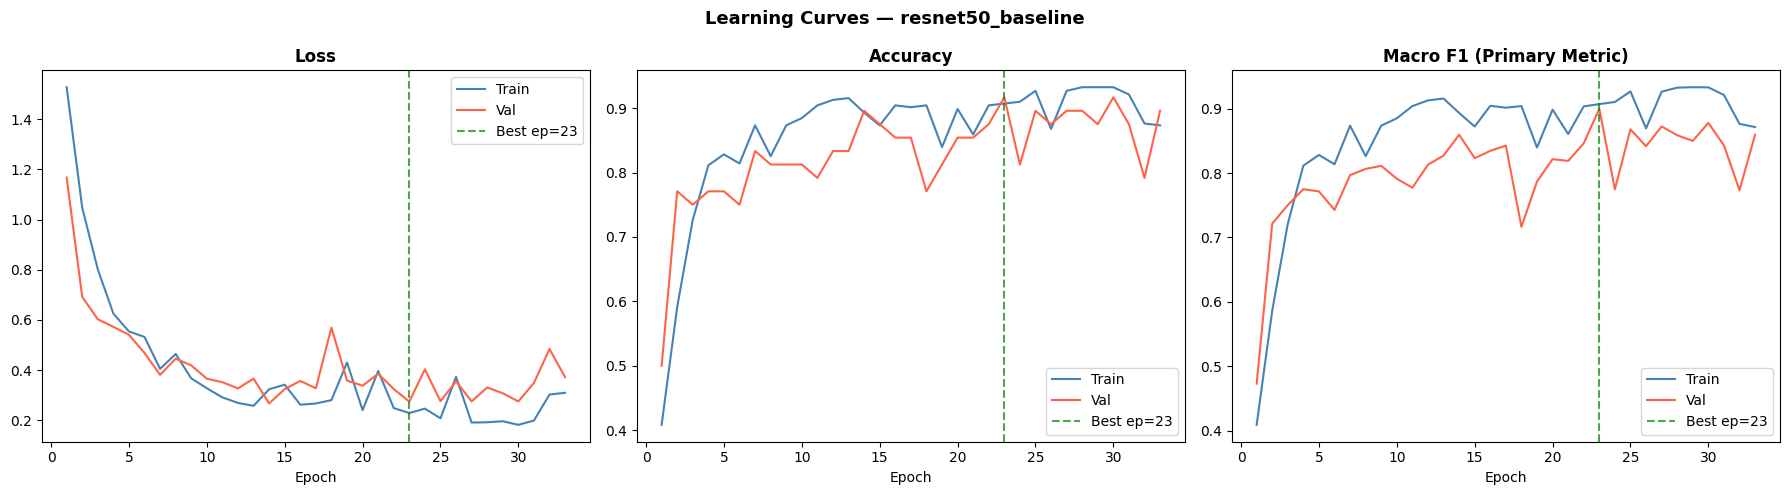

In [39]:
n = len(history['train_loss'])
x = range(1, n + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc'), ('train_f1','val_f1')],
    ['Loss', 'Accuracy', 'Macro F1 (Primary Metric)']
):
    ax.plot(x, history[metric[0]], label='Train', color='steelblue')
    ax.plot(x, history[metric[1]], label='Val',   color='tomato')
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best ep={best_epoch}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle(f'Learning Curves — {MODEL_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 14 — Test Set Evaluation (Best Checkpoint)

In [40]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print(f'Loaded best model from epoch {best_epoch}')

ts_loss, ts_acc, ts_f1, ts_auc, ts_preds, ts_labels, ts_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '='*50)
print('TEST SET RESULTS')
print('='*50)
print(f'  Accuracy  : {ts_acc*100:.2f}%')
print(f'  Macro F1  : {ts_f1*100:.2f}%   <- PRIMARY METRIC')
print(f'  AUC-ROC   : {ts_auc*100:.2f}%')
print(f'  Loss      : {ts_loss:.4f}')
print('='*50)

Loaded best model from epoch 23



TEST SET RESULTS
  Accuracy  : 83.33%
  Macro F1  : 82.45%   <- PRIMARY METRIC
  AUC-ROC   : 98.12%
  Loss      : 0.4942


## Step 15 — Classification Report (Per-Class)

In [41]:
ts_preds_np  = ts_preds.cpu().numpy()
ts_labels_np = ts_labels.cpu().numpy()

report = classification_report(ts_labels_np, ts_preds_np, target_names=CLASSES, digits=4)
print(report)

with open(f'{SAVE_DIR}/classification_report.txt', 'w') as f:
    f.write(f'Model: {MODEL_NAME}\nBest epoch: {best_epoch}\n')
    f.write(f'Test Accuracy : {ts_acc*100:.2f}%\n')
    f.write(f'Test Macro F1 : {ts_f1*100:.2f}%\n')
    f.write(f'Test AUC-ROC  : {ts_auc*100:.2f}%\n\n')
    f.write(report)
print(f'Saved to {SAVE_DIR}/classification_report.txt')

              precision    recall  f1-score   support

        Burn     0.9231    0.8000    0.8571        15
      Cancer     1.0000    0.7500    0.8571        12
       Lupus     0.6000    1.0000    0.7500         6
      Normal     0.8000    1.0000    0.8889         8
   Urticaria     0.8333    0.7143    0.7692         7

    accuracy                         0.8333        48
   macro avg     0.8313    0.8529    0.8245        48
weighted avg     0.8683    0.8333    0.8362        48

Saved to /root/outputs/resnet50_baseline/classification_report.txt


## Step 16 — Confusion Matrix

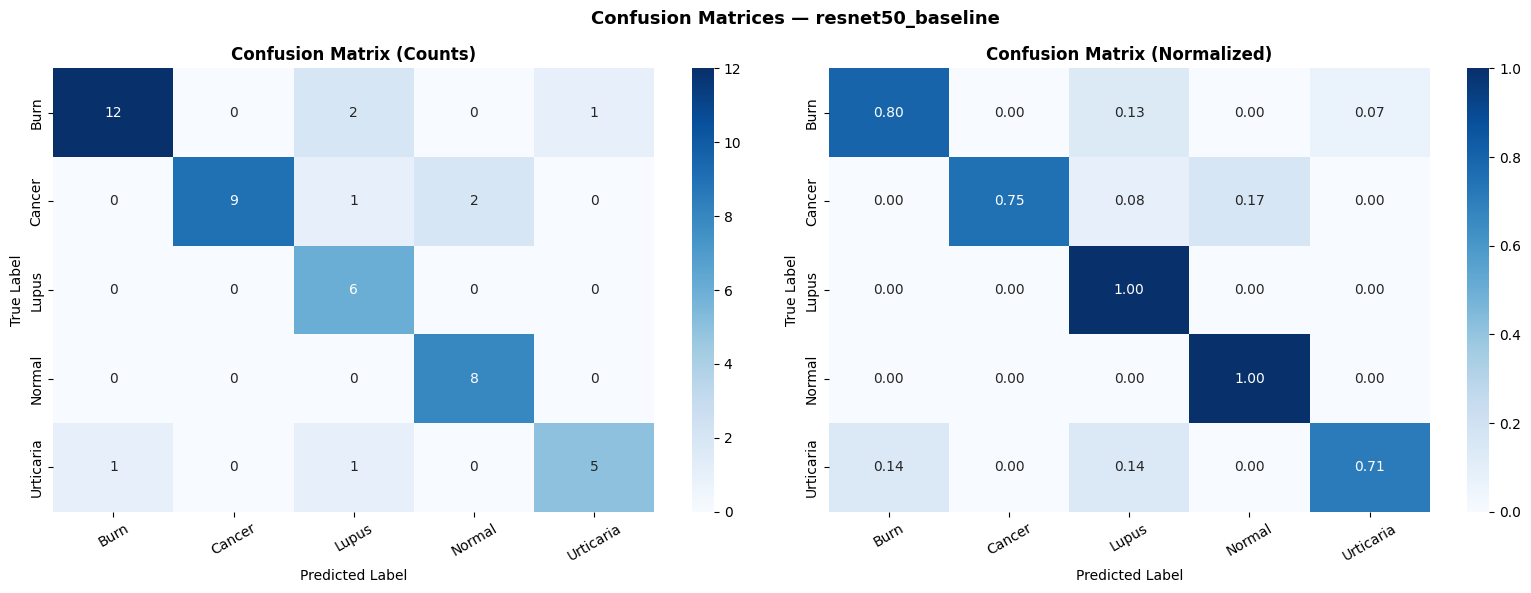

In [42]:
cm      = confusion_matrix(ts_labels_np, ts_preds_np)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Counts', 'Normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f'Confusion Matrix ({title})', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Confusion Matrices — {MODEL_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 17 — ROC Curves (Per Class + Macro Average)

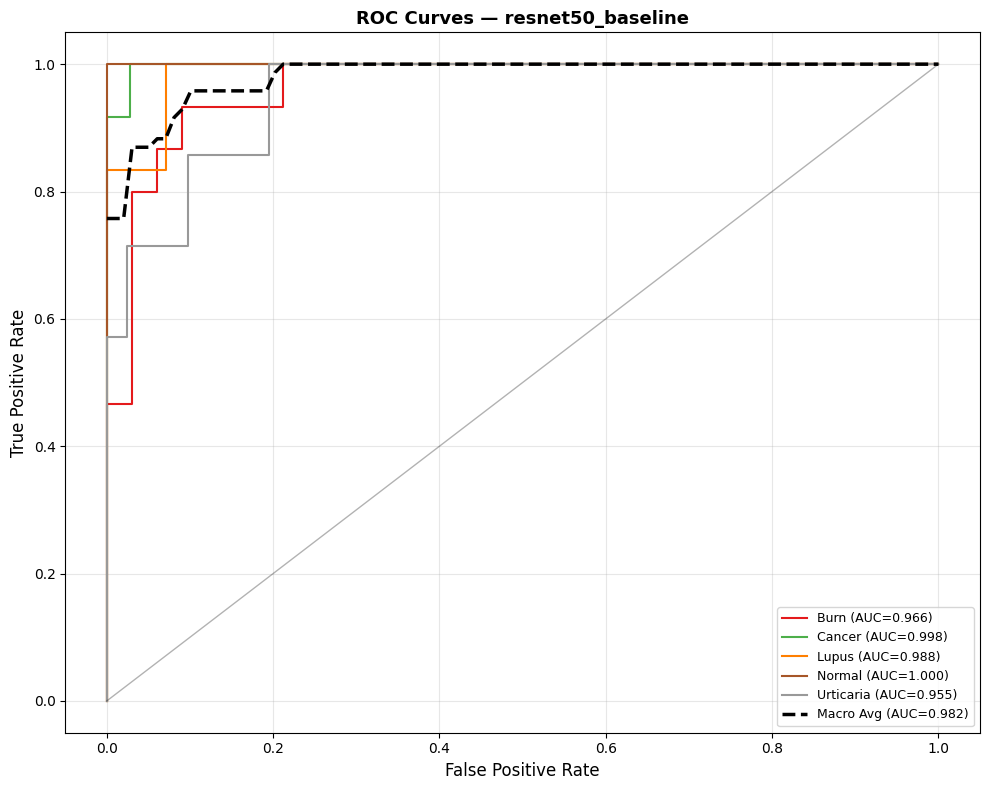

In [43]:
ts_probs_np = ts_probs.cpu().numpy()
y_bin       = label_binarize(ts_labels_np, classes=list(range(NUM_CLASSES)))
colors      = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))
mean_fpr    = np.linspace(0, 1, 100)
tprs        = []

fig, ax = plt.subplots(figsize=(10, 8))
for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], ts_probs_np[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{cls} (AUC={roc_auc:.3f})')
    tprs.append(np.interp(mean_fpr, fpr, tpr))

mean_tpr = np.mean(tprs, axis=0)
ax.plot(mean_fpr, mean_tpr, 'k--', lw=2.5,
        label=f'Macro Avg (AUC={auc(mean_fpr, mean_tpr):.3f})')
ax.plot([0,1],[0,1],'k-', lw=1, alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves — {MODEL_NAME}', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 18 — Final Summary

In [44]:
print('\n' + '='*60)
print(f'  FINAL RESULTS — {MODEL_NAME.upper()}')
print('='*60)
print(f'  Dataset       : 7-class skin disease, {len(df)} total images')
print(f'  Split         : Stratified 70/15/15')
print(f'  Balancing     : ROS on training only (after split)')
print(f'  Backbone      : ResNet50 pretrained ImageNet (frozen)')
print(f'  Best epoch    : {best_epoch}')
print('-'*60)
print(f'  Test Accuracy : {ts_acc*100:.2f}%')
print(f'  Test Macro F1 : {ts_f1*100:.2f}%   <- PRIMARY')
print(f'  Test AUC-ROC  : {ts_auc*100:.2f}%')
print('-'*60)
print(f'  Val Macro F1  : {best_val_f1*100:.2f}%  (checkpoint selection)')
print('='*60)
print(f'\nAll outputs saved to: {SAVE_DIR}')
print('  best model checkpoint (.pt)')
print('  learning curves (.png)')
print('  confusion matrices (.png)')
print('  ROC curves (.png)')
print('  classification report (.txt)')
print('  class distribution (.png)')
print('  sample images (.png)')


  FINAL RESULTS — RESNET50_BASELINE
  Dataset       : 7-class skin disease, 320 total images
  Split         : Stratified 70/15/15
  Balancing     : ROS on training only (after split)
  Backbone      : ResNet50 pretrained ImageNet (frozen)
  Best epoch    : 23
------------------------------------------------------------
  Test Accuracy : 83.33%
  Test Macro F1 : 82.45%   <- PRIMARY
  Test AUC-ROC  : 98.12%
------------------------------------------------------------
  Val Macro F1  : 89.97%  (checkpoint selection)

All outputs saved to: /root/outputs/resnet50_baseline
  best model checkpoint (.pt)
  learning curves (.png)
  confusion matrices (.png)
  ROC curves (.png)
  classification report (.txt)
  class distribution (.png)
  sample images (.png)
